# 03 — M3: the physics ablation (headline experiment)

**Question.** *How much physical feasibility does a physics-informed training loss buy a
graph-conditioned generative model of feeder time series — at what cost in statistical
fidelity?* This is this study's central claim, measured.

## Design (pre-registered before results)

- **Conditions:** identical training in every respect except the physics term —
  λ ∈ {0, 1e-3, 1e-2} on the mean squared power-balance residual (MVA²) of samples
  drawn *through the flow's inverse pass* each step (the penalty backpropagates through
  sampling). λ=1e-3 balances the two loss terms at initialization (measured: v0 samples
  have mean r² ≈ 400–1200 MVA², NLL/dim ≈ 2); λ=1e-2 tests dose-response. **3 seeds per
  condition** (42/43/44) — the dropout-calibration episode in the GridFM thesis recreation taught us what single runs are worth.
- **Physics loss:** full-Ybus nodal apparent-power mismatch (line charging and trafo taps
  included — series-only would be wrong), MATPOWER-form real arithmetic, differentiable
  end to end (`gridfm/physics.py`). Same quantity the M1 gate checks on real data.
- **Reference frame (measured in the calibration probe, rural0):**

| source | mean \|ΔS\| (MVA) | note |
|---|---|---|
| real days, float32 | 0.0005 | the M1 storage floor |
| PCA-K16 reconstruction of real days | 0.006 | **the representation floor — no generator in this basis can do better** |
| flow v0 (M2, λ=0) | 17.7 | statistics alone |
| independent bootstrap | 38.2 | wins the statistical scorecard, 2.2× worse physics — the gameable-metrics exhibit, quantified |

For scale: rural0's peak load is 7.5 MW — v0's mean mismatch is ~2.4× peak load.
Nothing about these samples solves a power flow; that is what λ must fix.

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
import sys; sys.path.insert(0, str(ROOT))
from gridfm.dataset import TimePCA, build_feeder, denormalize_days
from gridfm.flow import D_COND, GraphFlow, feeder_graph_tensors
from gridfm.physics import PhysicsHead

C = dict(blue="#2a78d6", aqua="#1baf7a", yellow="#eda100", green="#008300",
         violet="#4a3aa7", red="#e34948")
INK, INK2, MUTED, GRID, SURF = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURF, "axes.facecolor": SURF, "savefig.facecolor": SURF,
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.grid": True,
    "grid.color": GRID, "grid.linewidth": 0.8, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 10, "figure.dpi": 110,
})
RES = ROOT / "results" / "m3"
LCOLOR = {0.0: C["yellow"], 1e-3: C["aqua"], 1e-2: C["blue"]}
LLAB = {0.0: "λ = 0", 1e-3: "λ = 1e-3", 1e-2: "λ = 1e-2"}

runs = pd.read_csv(RES / "m3_runs.csv")
flows = runs[runs.kind == "flow"].copy()
base = runs[runs.kind == "baseline"].copy()
agg = (flows.groupby(["lam", "feeder"])
       .agg(resid_mean=("resid_mean_mva", "mean"), resid_sd=("resid_mean_mva", "std"),
            resid_max=("resid_max_mva", "mean"),
            W1_Vm=("W1_Vm", "mean"), W1_Vm_sd=("W1_Vm", "std"),
            W1_Pd=("W1_Pd", "mean"), acf=("ACF_head_rmse", "mean"),
            acf_sd=("ACF_head_rmse", "std"), xcorr=("XCorr_Pd_rmse", "mean"),
            ramps=("W1_head_ramps", "mean"), vm_oor=("vm_oor_pct", "mean"),
            div_vm=("div_vm_ratio", "mean"), div_pd=("div_pd_ratio", "mean"),
            val_nll=("val_nll", "mean"))
       .reset_index().round(4))
agg.to_csv(RES / "m3_ablation_summary.csv", index=False)
agg

,lam,feeder,resid_mean,resid_sd,resid_max,W1_Vm,W1_Vm_sd,W1_Pd,acf,acf_sd,xcorr,ramps,vm_oor,div_vm,div_pd,val_nll
0,0.000,rural0,14.4745,3.9648,561.4773,0.0010,0.0003,0.0024,0.2145,0.0591,0.2440,0.0951,0.0132,0.9020,0.8942,-1.9411
1,0.000,semiurb0,13.5143,3.6898,812.5545,0.0007,0.0002,0.0032,0.1055,0.0266,0.2427,0.2223,0.0011,0.8991,0.7735,-1.9411
2,0.001,rural0,1.1496,0.3702,37.1639,0.0221,0.0002,0.0087,0.6426,0.0274,0.3264,0.1279,1.0526,0.0339,0.4381,-1.9282
3,0.001,semiurb0,1.1243,0.3839,50.2087,0.0116,0.0002,0.0097,0.5088,0.0415,0.2732,0.2128,0.8696,0.0355,0.3667,-1.9282
4,0.010,rural0,1.1126,0.9846,34.2534,0.0167,0.0109,0.0328,0.6375,0.0667,0.4630,0.1371,1.0307,0.0167,0.1025,-1.7368
5,0.010,semiurb0,0.6489,0.1893,28.2142,0.0084,0.0054,0.0312,0.5198,0.0253,0.4230,0.2207,0.5827,0.0185,0.0860,-1.7368


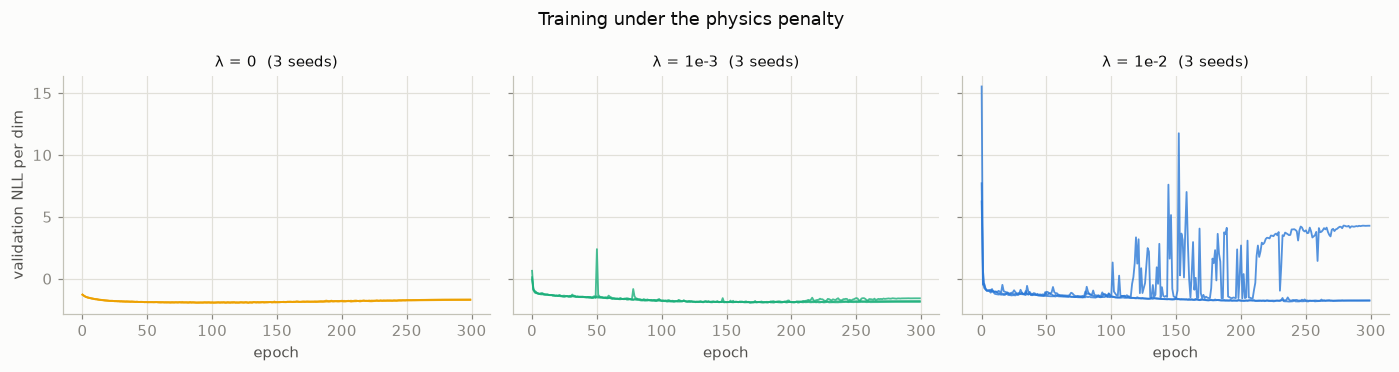

In [2]:
# fig09 — training: what the physics term does to the likelihood objective
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4), sharey=True)
for ax, lam_tag, lam in zip(axes, ["lam0", "lam1e3", "lam1e2"], [0.0, 1e-3, 1e-2]):
    for seed in [42, 43, 44]:
        h = pd.read_csv(RES / f"history_m3_{lam_tag}_s{seed}.csv")
        ax.plot(h.epoch, h.val_nll_per_dim, lw=1.2, color=LCOLOR[lam], alpha=0.8)
    ax.set_title(LLAB[lam] + "  (3 seeds)", fontsize=10)
    ax.set_xlabel("epoch")
# NOTE: the logged train column for physics runs is the TOTAL loss (NLL + physics
# term, ~1e10 at epoch 0 while the penalty tames 1000-MVA residuals) — not
# comparable to NLL, so only validation NLL (pure likelihood) is plotted.
axes[0].set_ylabel("validation NLL per dim")
fig.suptitle("Training under the physics penalty", fontsize=12)
fig.tight_layout(); fig.savefig(RES / "fig09_training.png", bbox_inches="tight")
plt.show()

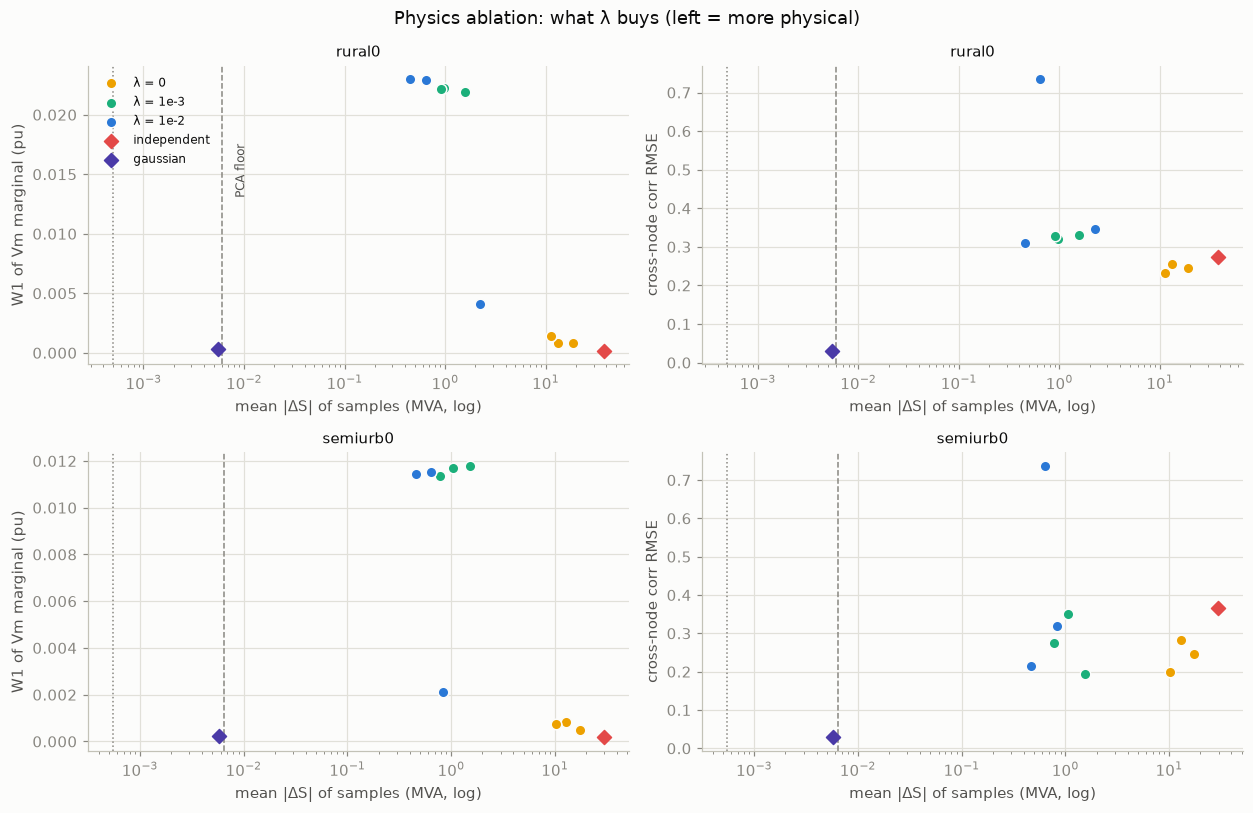

In [3]:
# fig10 — THE MONEY PLOT: feasibility (x) vs fidelity (y), all runs + references
fig, axes = plt.subplots(2, 2, figsize=(11.5, 7.5))
floors = base.set_index(["label", "feeder"])
for row, n in enumerate(["rural0", "semiurb0"]):
    for col, (met, mlab) in enumerate([("W1_Vm", "W1 of Vm marginal (pu)"),
                                       ("XCorr_Pd_rmse", "cross-node corr RMSE")]):
        ax = axes[row, col]
        for lam in [0.0, 1e-3, 1e-2]:
            sub = flows[(flows.lam == lam) & (flows.feeder == n)]
            ax.scatter(sub.resid_mean_mva, sub[met], s=48, color=LCOLOR[lam],
                       label=LLAB[lam] if (row == 0 and col == 0) else None,
                       zorder=3, edgecolors=SURF, linewidths=1)
        for blab, bcol in [("independent", C["red"]), ("gaussian", C["violet"])]:
            b = floors.loc[(blab, n)]
            ax.scatter(b.resid_mean_mva, b[met], marker="D", s=42, color=bcol,
                       label=blab if (row == 0 and col == 0) else None, zorder=3)
        pcafl = floors.loc[("pca_ceiling", n)].resid_mean_mva
        ax.axvline(pcafl, color=MUTED, lw=1, ls="--")
        f32 = floors.loc[("real_float32", n)].resid_mean_mva
        ax.axvline(f32, color=MUTED, lw=1, ls=":")
        ax.set_xscale("log")
        ax.set_xlabel("mean |ΔS| of samples (MVA, log)")
        ax.set_ylabel(mlab)
        ax.set_title(f"{n}", fontsize=10)
axes[0, 0].legend(frameon=False, fontsize=8, loc="upper left")
axes[0, 0].annotate("PCA floor", xy=(0.008, axes[0, 0].get_ylim()[1] * 0.55),
                    fontsize=8, color=INK2, rotation=90)
fig.suptitle("Physics ablation: what λ buys (left = more physical)", fontsize=12)
fig.tight_layout(); fig.savefig(RES / "fig10_money.png", bbox_inches="tight")
plt.show()

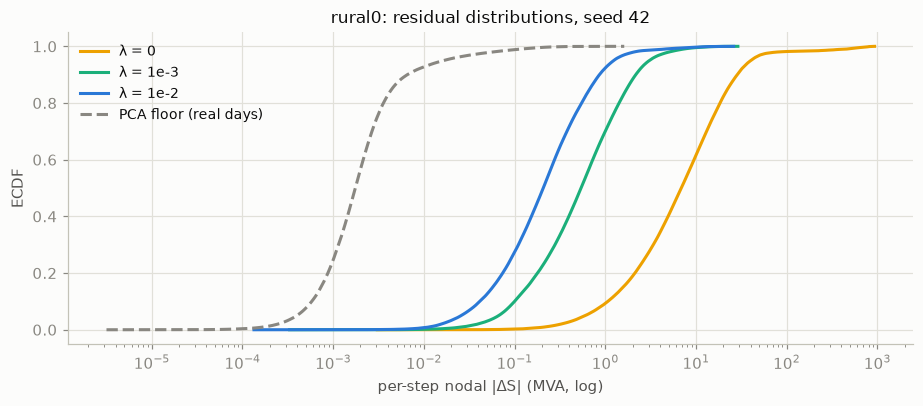

In [4]:
# fig11 — residual distributions: one seed per condition, ECDF over per-step residuals
device = "cuda" if torch.cuda.is_available() else "cpu"
pca = TimePCA.load(ROOT / "checkpoints" / "timepca_k16.npz")
n = "rural0"
f = build_feeder(ROOT / "data" / "m1" / f"{n}_year.npz")
head = PhysicsHead(f, pca).to(device)
g = feeder_graph_tensors(f, device)

def resid_of(tag):
    ck = torch.load(ROOT / "checkpoints" / f"{tag}_best.pt", map_location=device,
                    weights_only=False)
    a = ck["args"]
    m = GraphFlow(6 * a["k"], D_COND, n_layers=a["layers"], hidden=a["hidden"]).to(device)
    m.load_state_dict(ck["model"]); m.eval()
    days = torch.as_tensor(denormalize_days(pca.decode(m.sample(100, g).cpu().numpy()),
                                            f["static"]), dtype=torch.float32, device=device)
    with torch.no_grad():
        return head.residual_mva(days).cpu().numpy().ravel()

fig, ax = plt.subplots(figsize=(8.5, 3.8))
for lam_tag, lam in [("lam0", 0.0), ("lam1e3", 1e-3), ("lam1e2", 1e-2)]:
    r = np.sort(resid_of(f"m3_{lam_tag}_s42"))
    ax.plot(r, np.linspace(0, 1, len(r)), lw=2, color=LCOLOR[lam], label=LLAB[lam])
rec = denormalize_days(pca.decode(pca.encode(f["days_pu"][f["val_idx"]])), f["static"])
with torch.no_grad():
    rr = np.sort(head.residual_mva(torch.as_tensor(rec, dtype=torch.float32,
                                                   device=device)).cpu().numpy().ravel())
ax.plot(rr, np.linspace(0, 1, len(rr)), lw=2, color=MUTED, ls="--",
        label="PCA floor (real days)")
ax.set_xscale("log"); ax.set_xlabel("per-step nodal |ΔS| (MVA, log)")
ax.set_ylabel("ECDF"); ax.legend(frameon=False, fontsize=9)
ax.set_title("rural0: residual distributions, seed 42", fontsize=11)
fig.tight_layout(); fig.savefig(RES / "fig11_ecdf.png", bbox_inches="tight")
plt.show()

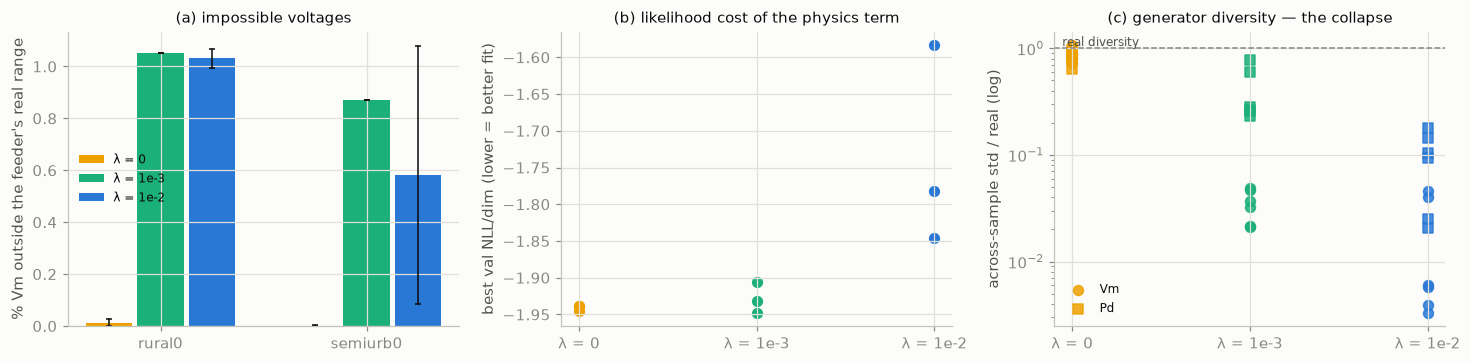

In [5]:
# fig12 — the side effects: impossible voltages, likelihood cost, DIVERSITY COLLAPSE
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.4))
ax = axes[0]
w = 0.25
for i, lam in enumerate([0.0, 1e-3, 1e-2]):
    for j, n in enumerate(["rural0", "semiurb0"]):
        sub = flows[(flows.lam == lam) & (flows.feeder == n)]
        ax.bar(j + (i - 1) * w, sub.vm_oor_pct.mean(), width=w * 0.9,
               color=LCOLOR[lam], label=LLAB[lam] if j == 0 else None)
        ax.errorbar(j + (i - 1) * w, sub.vm_oor_pct.mean(), yerr=sub.vm_oor_pct.std(),
                    color=INK, lw=1, capsize=2)
ax.set_xticks([0, 1]); ax.set_xticklabels(["rural0", "semiurb0"])
ax.set_ylabel("% Vm outside the feeder's real range")
ax.set_title("(a) impossible voltages", fontsize=10)
ax.legend(frameon=False, fontsize=8)

ax = axes[1]
for lam in [0.0, 1e-3, 1e-2]:
    sub = flows[flows.lam == lam].groupby("seed").val_nll.mean()
    ax.scatter([LLAB[lam]] * len(sub), sub, s=40, color=LCOLOR[lam])
ax.set_ylabel("best val NLL/dim (lower = better fit)")
ax.set_title("(b) likelihood cost of the physics term", fontsize=10)

ax = axes[2]                    # the collapse panel — the finding of this milestone
for i, (col, mk, lab) in enumerate([("div_vm_ratio", "o", "Vm"),
                                    ("div_pd_ratio", "s", "Pd")]):
    for lam in [0.0, 1e-3, 1e-2]:
        sub = flows[flows.lam == lam]
        ax.scatter([LLAB[lam]] * len(sub), sub[col], s=42, marker=mk,
                   color=LCOLOR[lam], alpha=0.85,
                   label=lab if lam == 0.0 else None)
ax.axhline(1.0, color=MUTED, lw=1, ls="--")
ax.annotate("real diversity", xy=(0.02, 1.05), xycoords=("axes fraction", "data"),
            fontsize=8, color=INK2)
ax.set_yscale("log")
ax.set_ylabel("across-sample std / real (log)")
ax.set_title("(c) generator diversity — the collapse", fontsize=10)
ax.legend(frameon=False, fontsize=8, loc="lower left")
fig.tight_layout(); fig.savefig(RES / "fig12_side_effects.png", bbox_inches="tight")
plt.show()

## Reading the results — the ablation answered, with a twist

**1. The physics loss works on its own axis** (fig10, fig11): mean sample residual drops
from 10.0–18.7 MVA (λ=0, seed spread) to 0.77–1.6 MVA at λ=1e-3 — a **12–17×
improvement, consistent across all 3 seeds and both feeders**. λ=1e-2 saturates
(0.46–2.2 MVA): more dose does not buy more physics.

**2. But part of the mechanism is pathological.** The diversity panel (fig12c) shows
how the penalty gets its residual down: at λ=1e-3 the across-sample voltage variability
collapses to **~3% of real** (with a −2.2% systematic Vm shift — that is exactly the
W1_Vm degradation in fig10); at λ=1e-2, one seed collapses in *all* channels
(Pd diversity ratio 0.02 — the model emits essentially one repeated day, whose pooled
marginals look deceptively fine). Mean-squared residual is minimized by shrinking the
sample distribution toward its most-feasible point; maximum likelihood resists, but
loses wherever the data density is flat. **A scenario generator with one scenario is
useless — and pooled statistical metrics cannot see this failure.** Across-sample
diversity is hereby a first-class metric in this repo's evaluation suite.

**3. The quiet bombshell is the Gaussian baseline** (fig10, diamonds): the day-PCA
Gaussian sits at the **representation floor** (0.0055 MVA — 200× more physical than
the physics-trained flow) with healthy diversity. Why: its samples live in the linear
span of *solved* days, and at MV-feeder scale (Vm within ±5%, small angles) the AC
power-flow manifold is **locally near-affine** — any point in the span of solutions is
approximately a solution. The free flow wanders off this manifold (17 MVA); the penalty
pushes it partway back (1 MVA) while damaging diversity; the linear model never leaves.

**4. What this means for the architecture (sets M4):** the right way to get physics
into this generator is not (only) a sample penalty — it is the *representation*:
generate within a day-level subspace spanned by feasible days (Cramer's PCA-flow
structure, which we now understand as a physics device, not just compression), and let
the flow model the distribution *within* that subspace — where its job is exactly what
Gaussians do badly: tails, multimodality (fig08 M2), and conditioning. This also
attacks M2's weakest result (cross-node correlation RMSE 0.21 vs the Gaussian's 0.03),
since the day-subspace carries the feeder-wide correlation by construction.

## Assumptions & scope notes

- λ chosen by initial gradient-magnitude balancing (1e-3) plus one dose point (1e-2);
  no full sweep (budget honesty — the qualitative picture is dose-saturated already).
- Physics penalty backpropagates through 8 sampled days per training step; more might
  regularize the collapse but cannot fix its cause (the objective's optimum is
  concentrated mass).
- All numbers on train feeders' held-out days; transfer to comm0 remains M5's exam.
- The collapse finding echoes the thesis-recreation dropout-calibration lesson: **multi-seed +
  looking at the samples caught what the headline metric alone would have hidden.**